In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data= pd.read_csv('Employee.csv')

In [3]:
print("Shape:",data.shape)

Shape: (1470, 35)


In [4]:
print("\nColumn Data Types:\n",data.dtypes)


Column Data Types:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64

In [5]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
print("\nMissing Valuse:\n",data.isnull().sum())


Missing Valuse:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole    

In [7]:
print("Duplicate rows:",data.duplicated().sum())

Duplicate rows: 0


In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


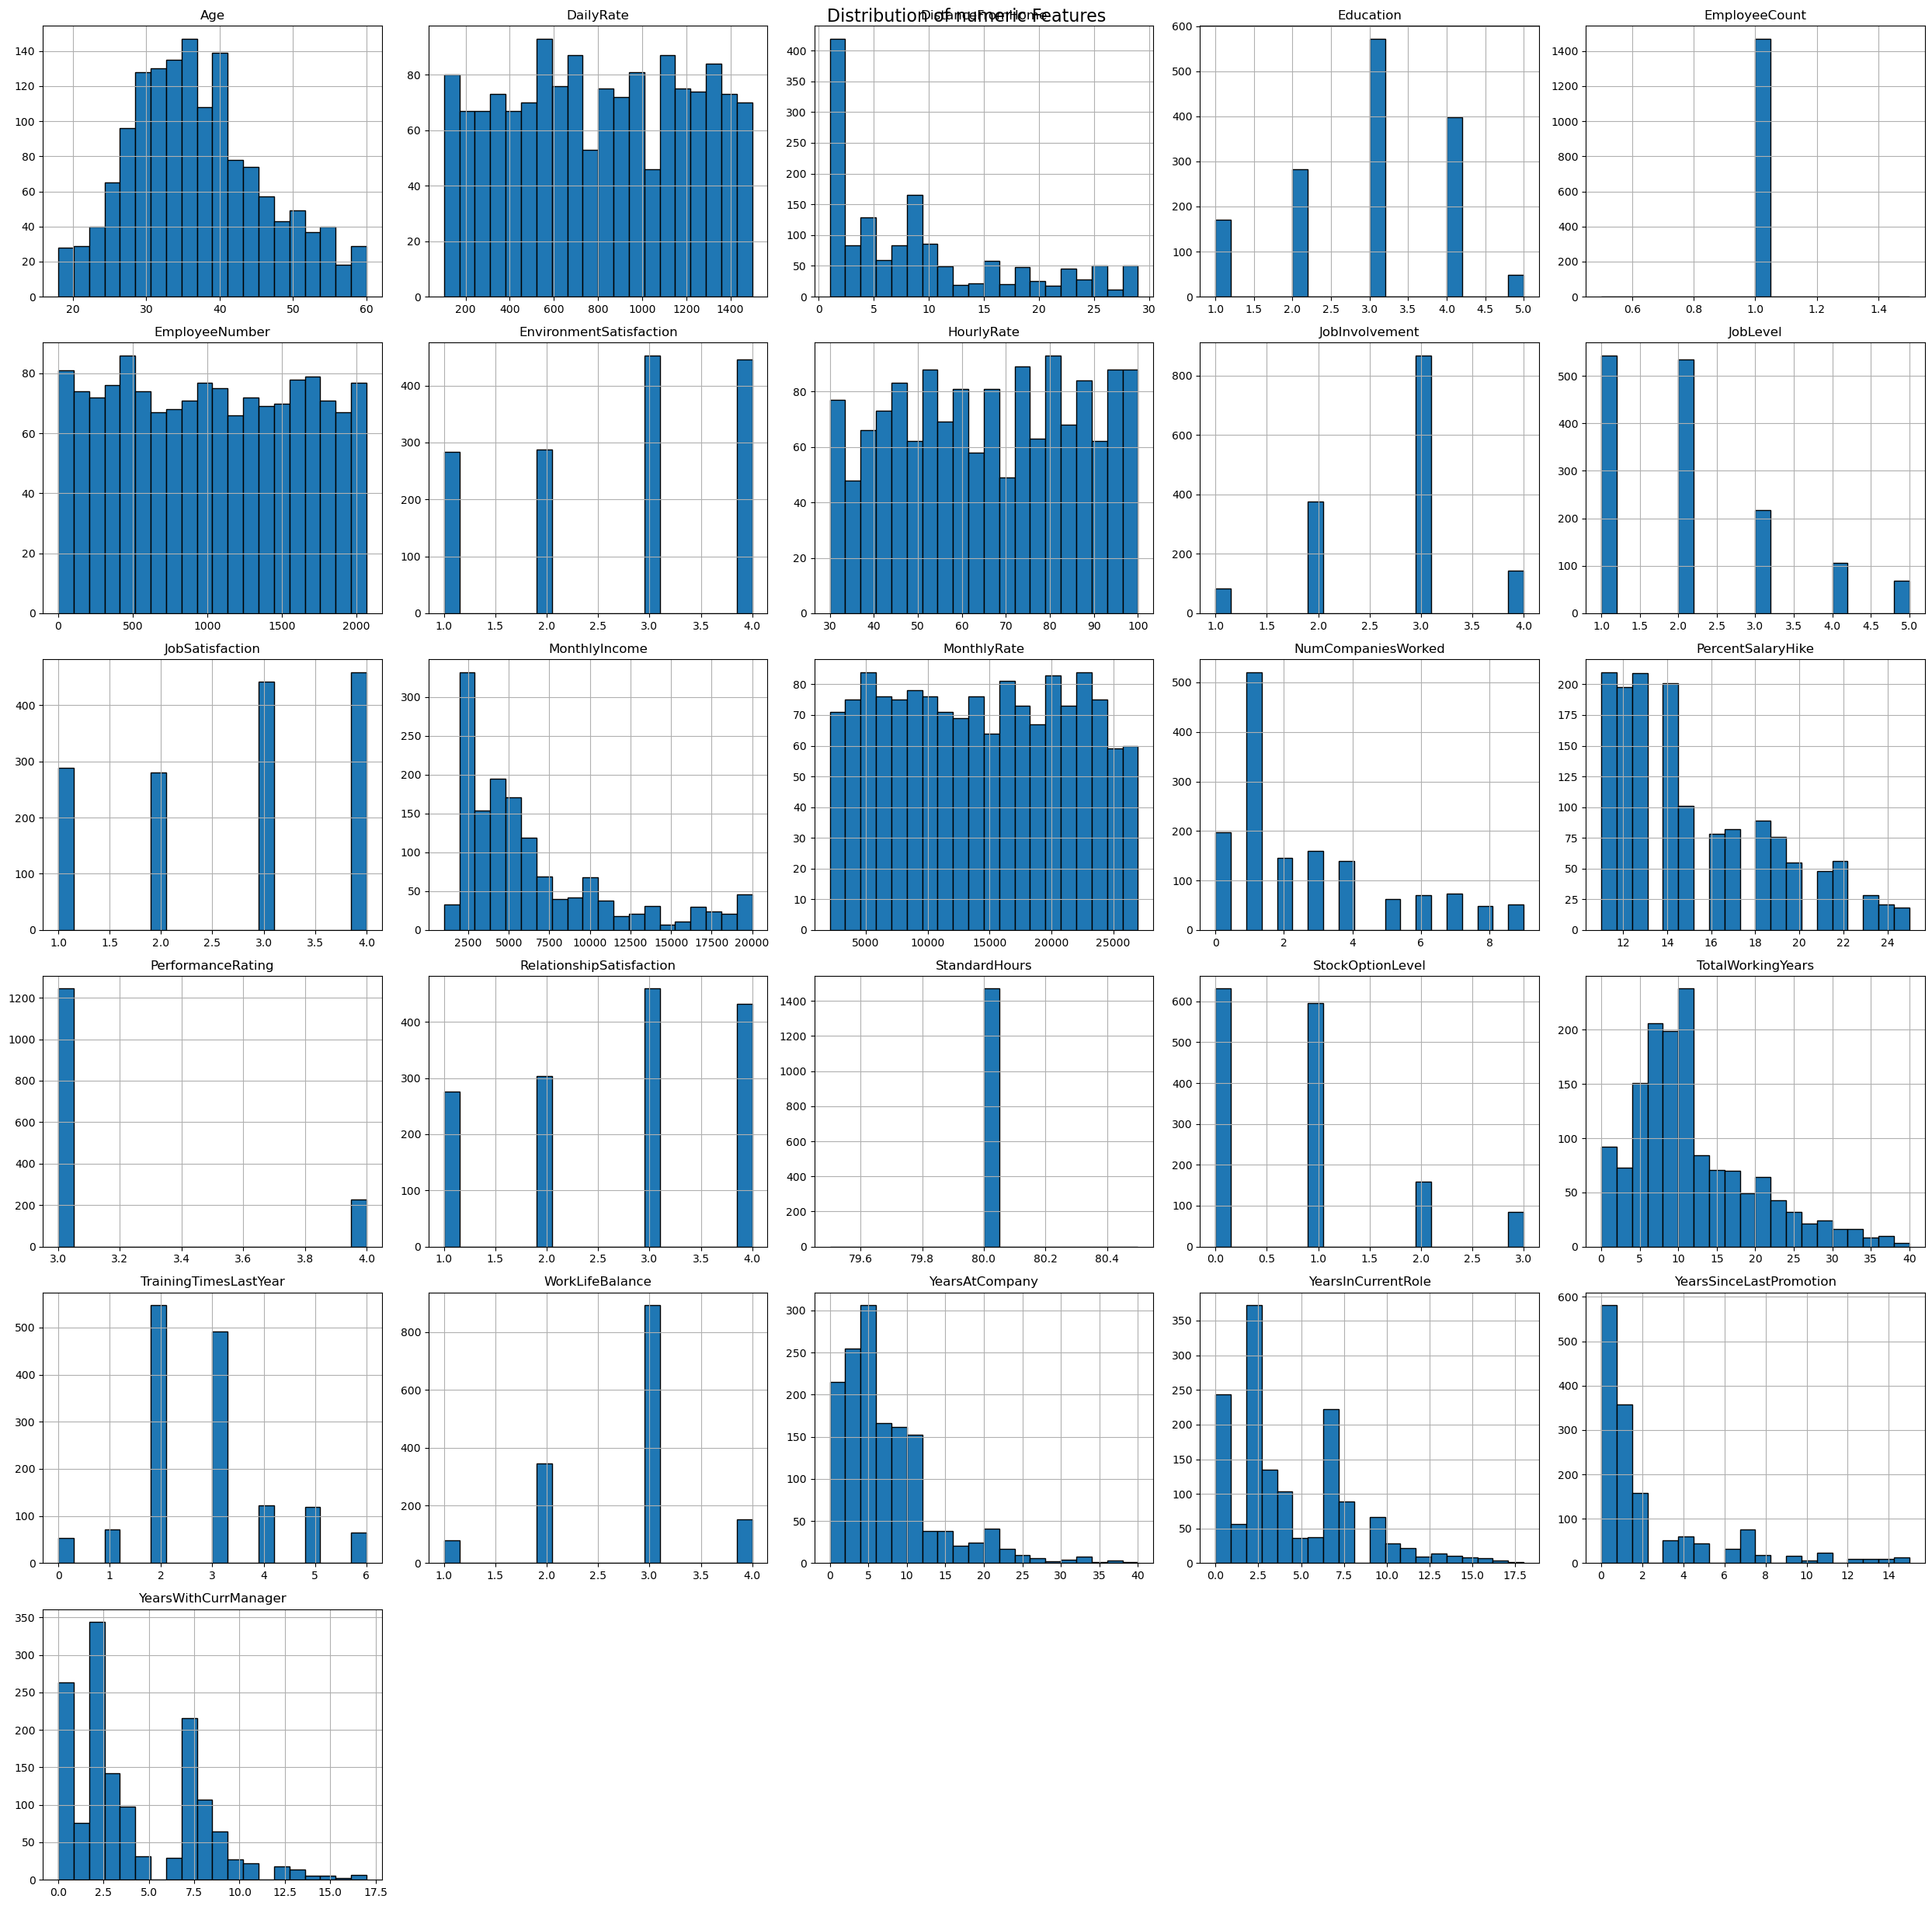

In [9]:
data.hist(figsize=(25,25),bins=20, edgecolor='black')
plt.suptitle("Distribution of numeric Features",fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
categorical= data.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:",categorical)
print("Count:", len(categorical))

Categorical Columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Count: 9


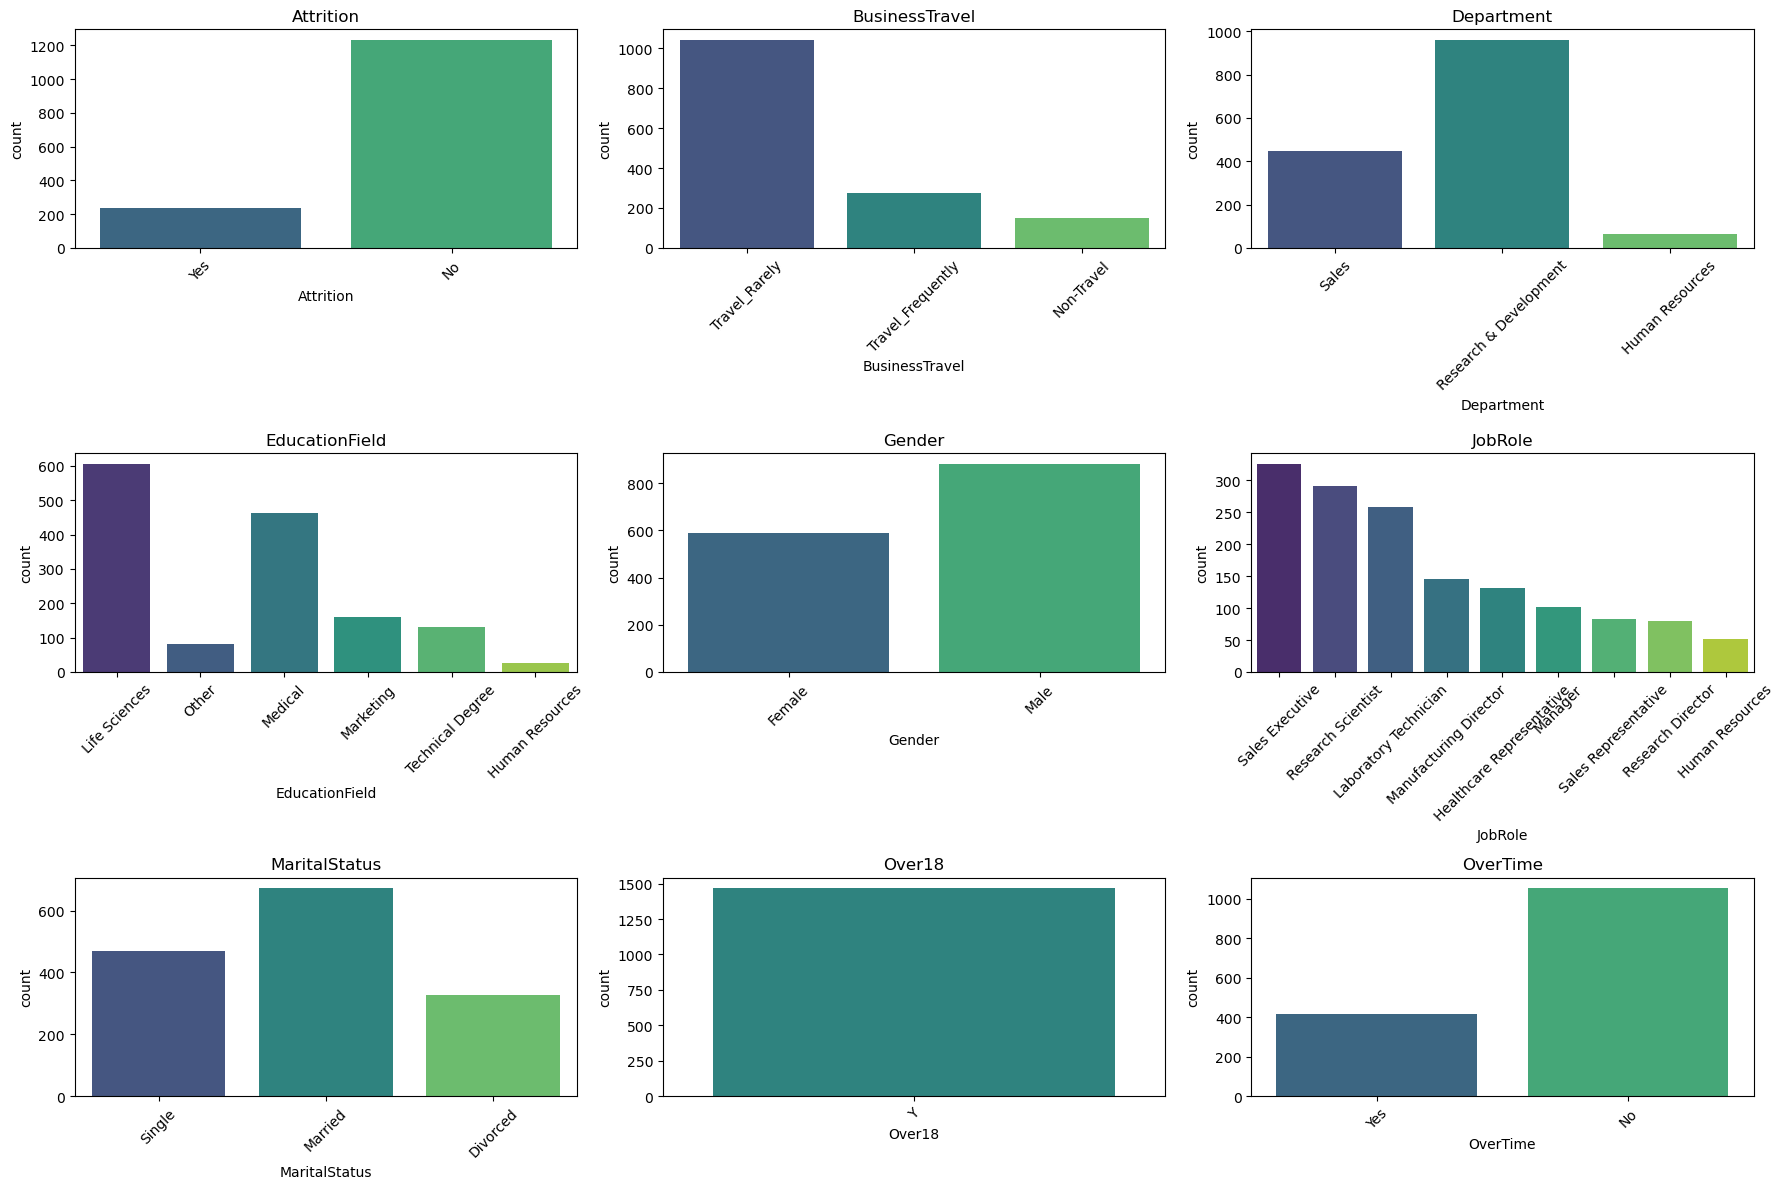

In [11]:
n_cols=3
n_rows= int(np.ceil(len(categorical)/n_cols))

fig,axes = plt.subplots(n_rows,n_cols,figsize=(18,4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(categorical):
    sns.countplot(data=data, x=col, ax=axes[i], hue=col, palette='viridis', legend=False)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
#correlation matrix for numeric columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = data[numeric_cols].corr()


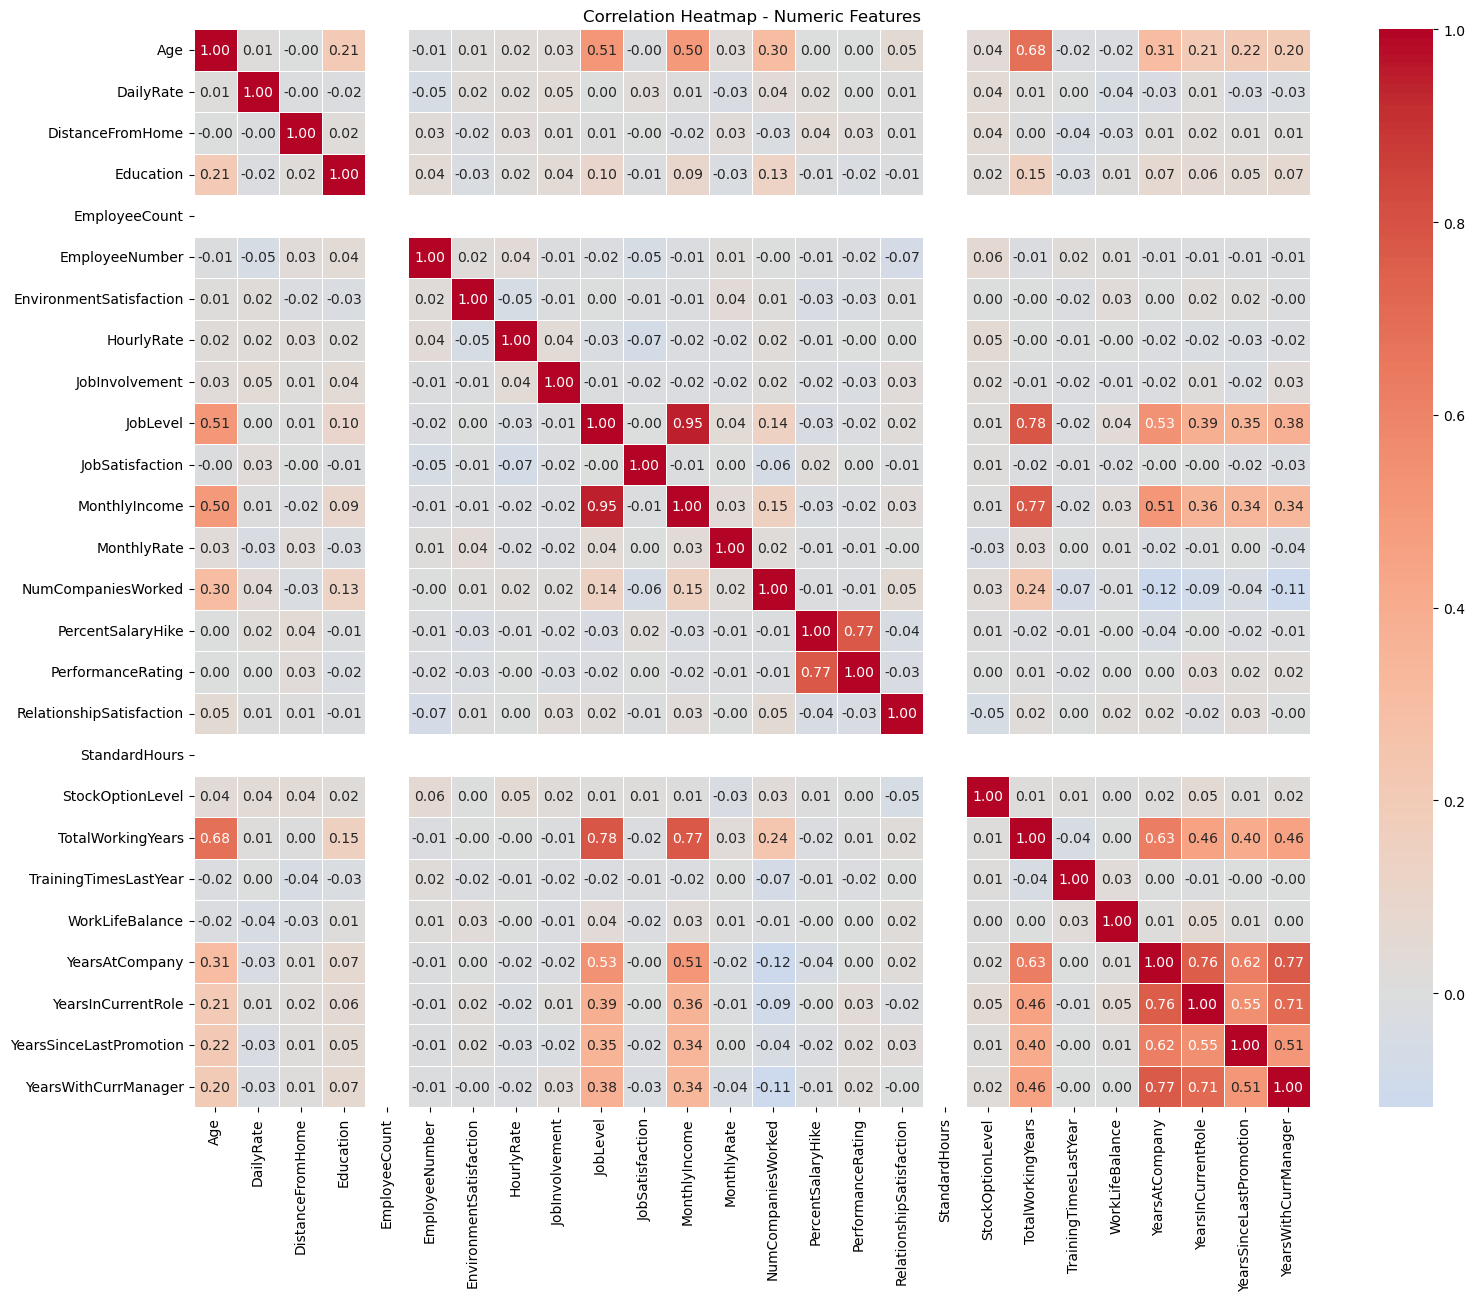

In [13]:
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

In [14]:
data_corr=data.copy()
data_corr['Attrition_num'] = data_corr['Attrition'].map({'Yes': 1,'No' : 0})
target_corr =data_corr[numeric_cols.tolist() + ['Attrition_num']].corr()['Attrition_num'].drop('Attrition_num').sort_values(ascending=False)


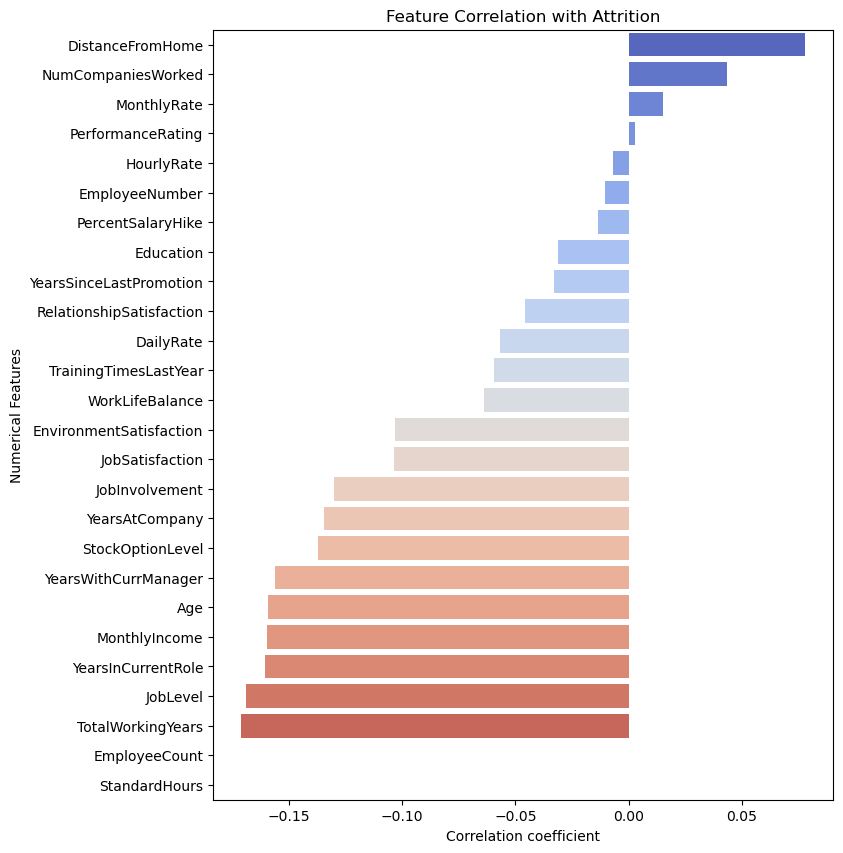

In [15]:
plt.figure(figsize=(8, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette='coolwarm', legend=False)
plt.title('Feature Correlation with Attrition')
plt.xlabel('Correlation coefficient')
plt.ylabel('Numerical Features')
plt.show()


In [16]:
from scipy.stats import chi2_contingency

In [17]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Attrition')

cramers_results = {col: cramers_v(data[col], data['Attrition']) for col in categorical_cols}
cramers_series = pd.Series(cramers_results).sort_values(ascending=False)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16508\1409780077.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / min(k - 1, r - 1))


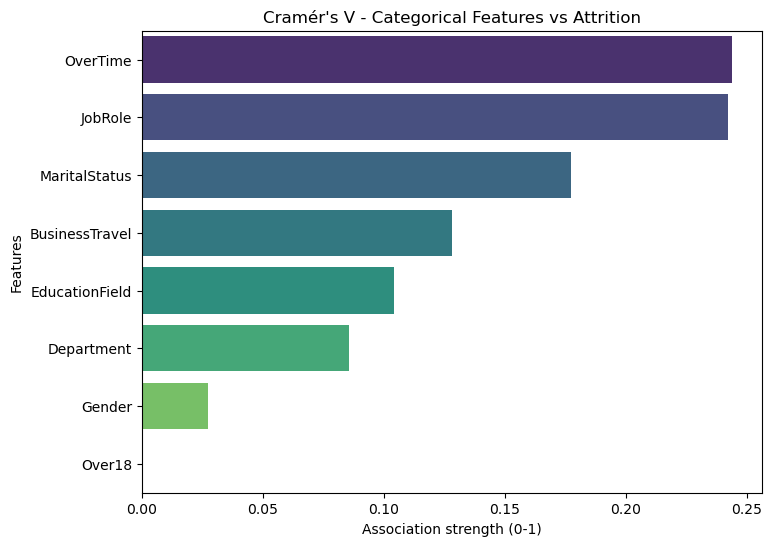

In [18]:
plt.figure(figsize=(8, 6))
sns.barplot(x=cramers_series.values, y=cramers_series.index, hue=cramers_series.index, palette='viridis', legend=False)
plt.title("Cramér's V - Categorical Features vs Attrition")
plt.xlabel("Association strength (0-1)")
plt.ylabel("Features")
plt.show()

In [19]:
constant_cols = [col for col in data.columns if data[col].nunique() == 1]
print("Constant columns:", constant_cols)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [20]:
id_cols = [col for col in data.columns if data[col].nunique() == len(data)]
print("ID-like columns:", id_cols)

ID-like columns: ['EmployeeNumber']


In [21]:
cols_to_drop = constant_cols + id_cols
print("Dropping:", cols_to_drop)

data = data.drop(columns=cols_to_drop)
print("New shape after dropping:", data.shape)

Dropping: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New shape after dropping: (1470, 31)


sanity check -confirm no constant/ID columns remain


In [22]:
remaining_constants = [col for col in data.columns if data[col].nunique() == 1]
remaining_ids = [col for col in data.columns if data[col].nunique() == len(data)]
print("Remaining constants:", remaining_constants)
print("Remaining ID-like columns:", remaining_ids)

Remaining constants: []
Remaining ID-like columns: []


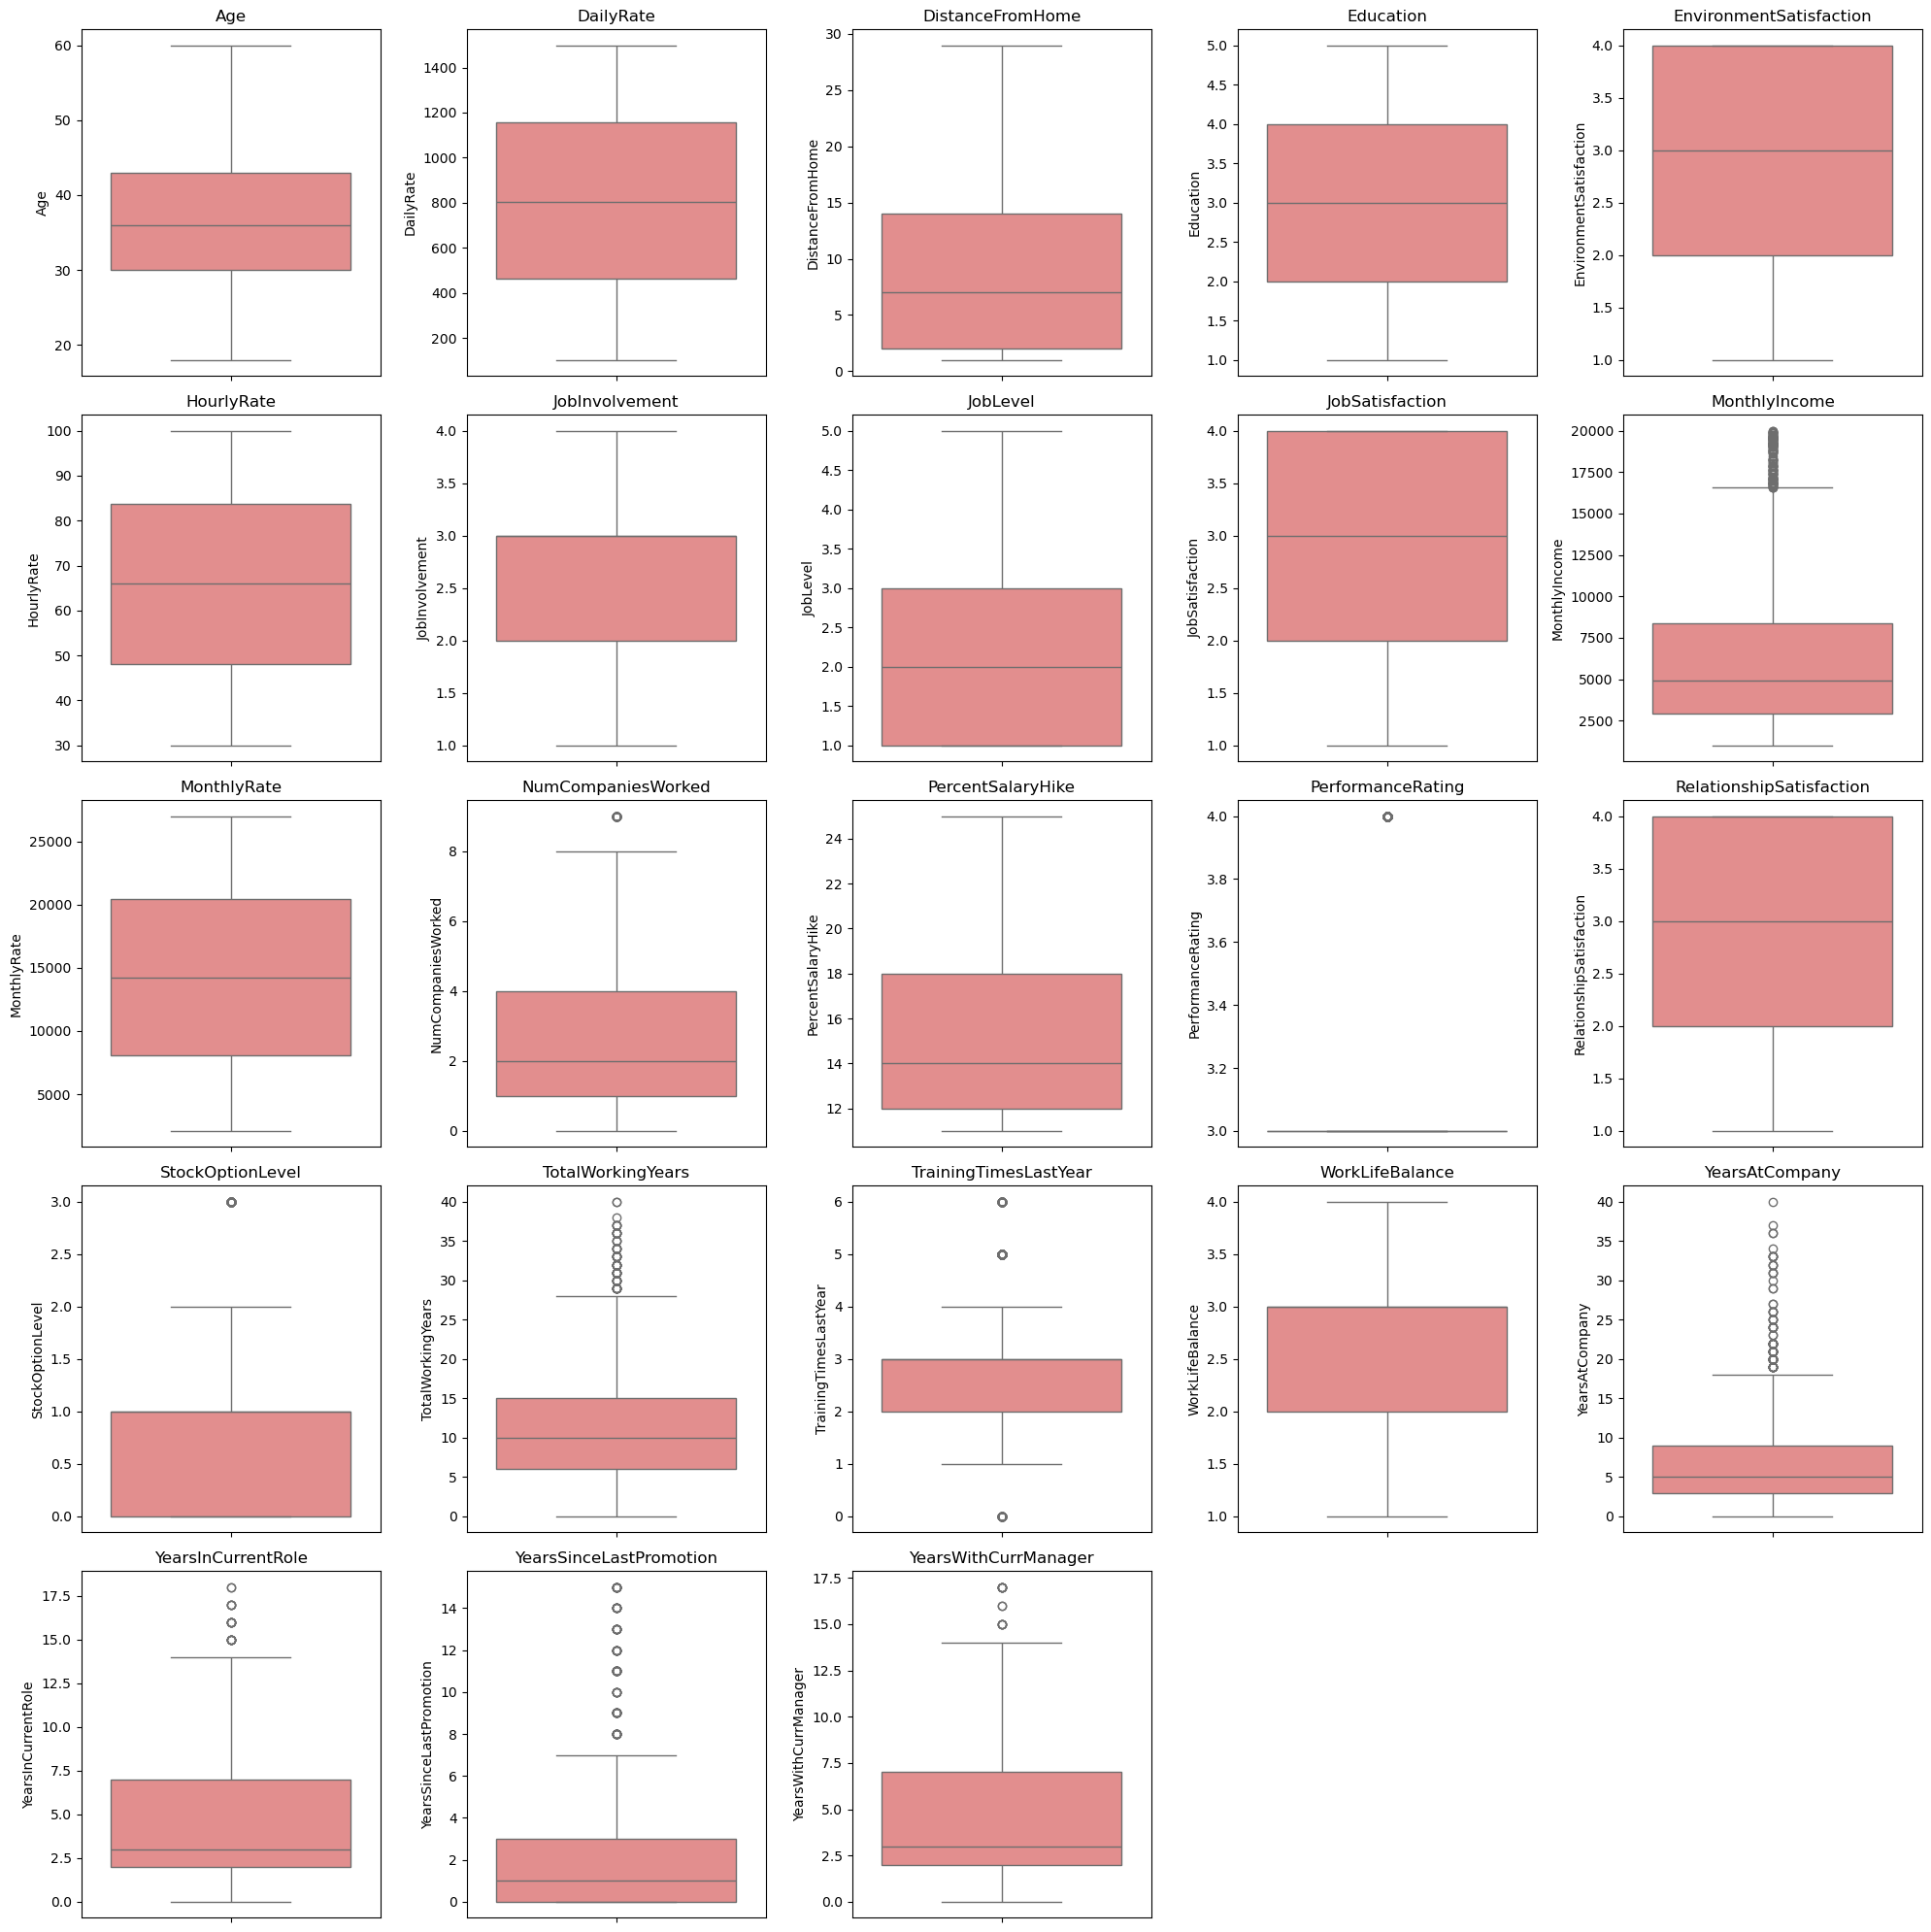

In [23]:
# Step 1: Visualize outliers using boxplots
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

n_cols = 5
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [24]:
# Step 2: Define IQR-based capping function
def cap_outliers_iqr(data, cols):
    df = data.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df

In [25]:
# Step 3: Choose which columns to cap
# Typically apply to continuous numeric columns, NOT ordinal/rating scales (1-4/1-5) 
# since capping doesn't make sense for already-bounded categorical-like scores
cols_to_cap = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 
               'YearsInCurrentRole', 'YearsWithCurrManager', 
               'YearsSinceLastPromotion', 'NumCompaniesWorked', 
               'DistanceFromHome', 'PercentSalaryHike']

data= cap_outliers_iqr(data, cols_to_cap)

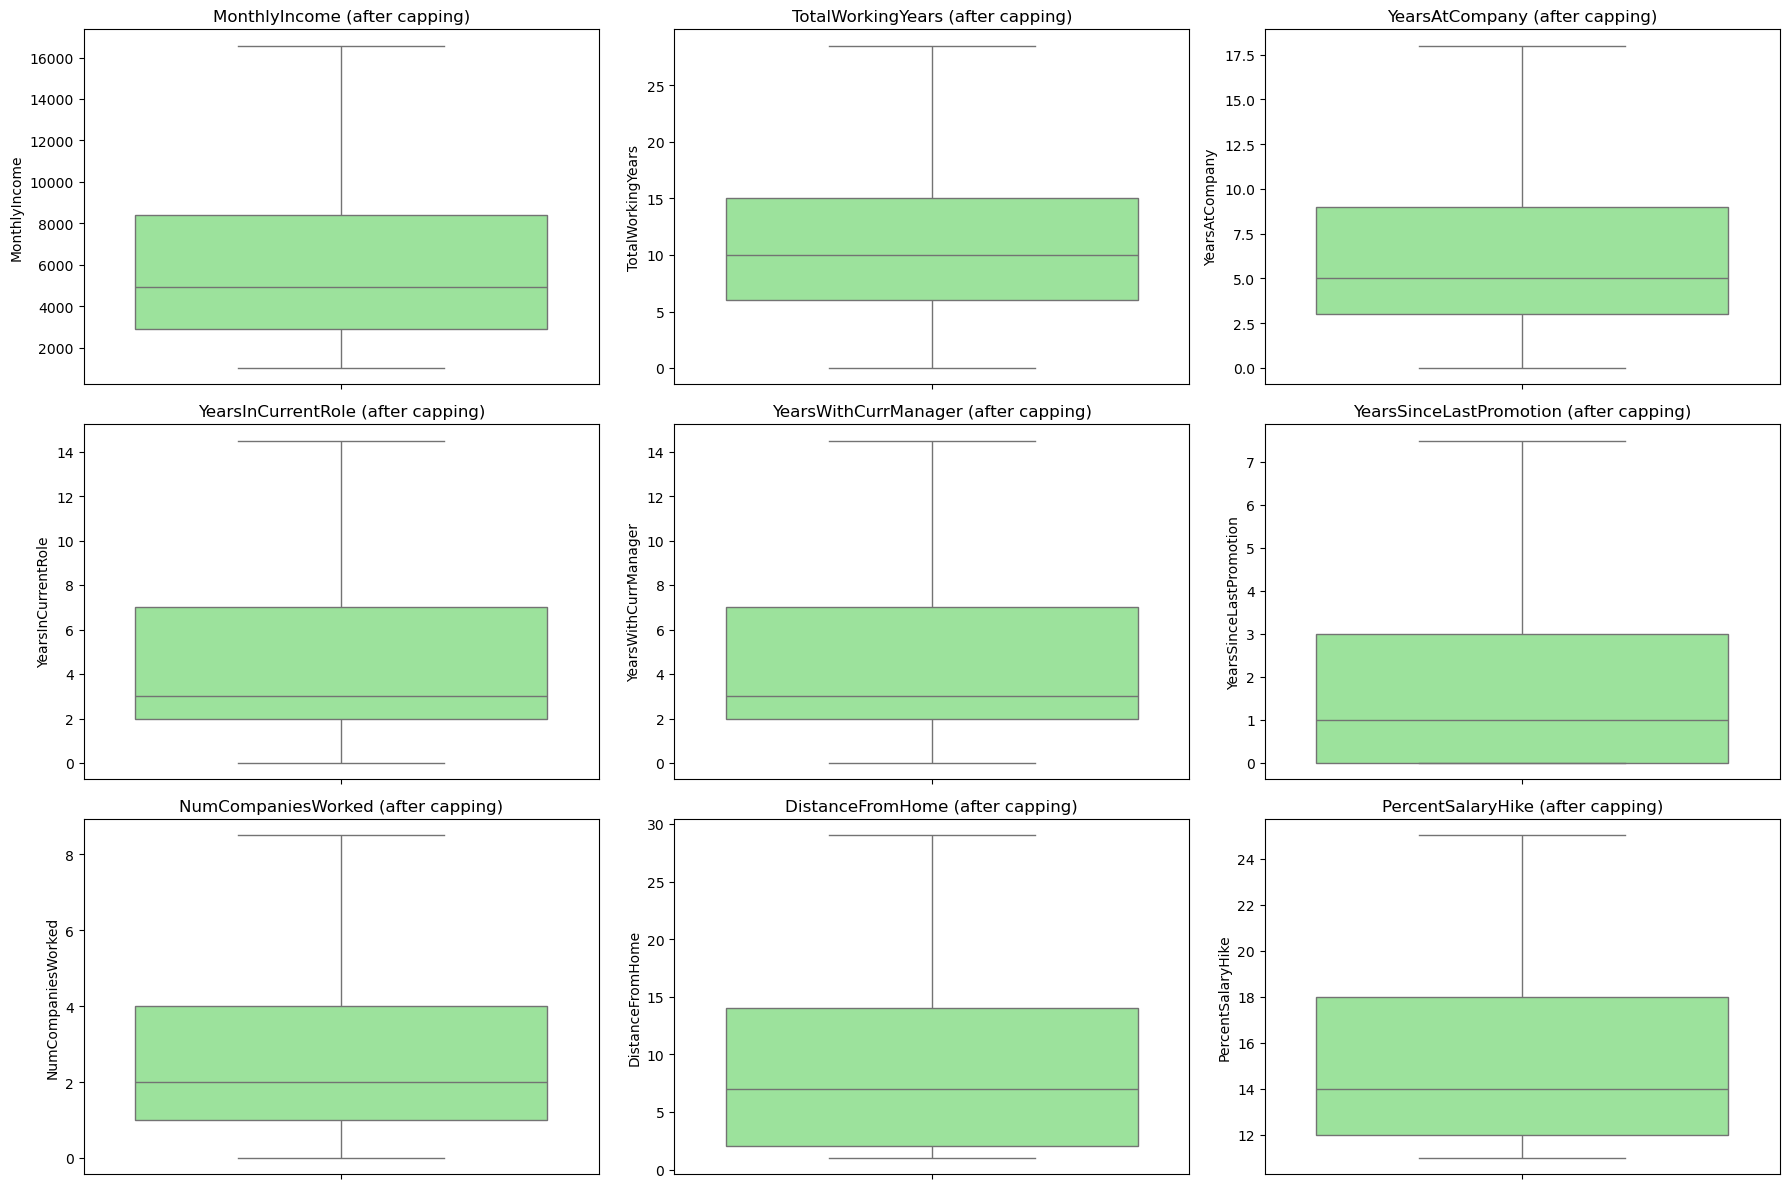

In [26]:
# Step 4: Re-check boxplots after capping to confirm effect
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(cols_to_cap):
    sns.boxplot(y=data[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{col} (after capping)')
plt.tight_layout()
plt.show()

In [27]:
# Step 1: Check skewness of numeric columns
skew_vals = data[numeric_cols].skew().sort_values(ascending=False)
print(skew_vals)

PerformanceRating           1.921883
YearsSinceLastPromotion     1.262563
MonthlyIncome               1.168595
JobLevel                    1.025401
NumCompaniesWorked          0.971516
StockOptionLevel            0.968980
DistanceFromHome            0.958118
YearsAtCompany              0.900774
TotalWorkingYears           0.855518
PercentSalaryHike           0.821128
YearsInCurrentRole          0.803704
YearsWithCurrManager        0.741000
TrainingTimesLastYear       0.553124
Age                         0.413286
MonthlyRate                 0.018578
DailyRate                  -0.003519
HourlyRate                 -0.032311
Education                  -0.289681
RelationshipSatisfaction   -0.302828
EnvironmentSatisfaction    -0.321654
JobSatisfaction            -0.329672
JobInvolvement             -0.498419
WorkLifeBalance            -0.552480
dtype: float64


In [28]:
# Step 2: Identify columns with high positive skew (right-skewed)
skewed_cols = skew_vals[skew_vals > 0.75].index.tolist()
# Exclude ordinal/rating columns even if flagged - log transform doesn't make sense for them
skewed_cols = [col for col in skewed_cols if col not in 
               ['PerformanceRating', 'JobLevel', 'StockOptionLevel']]
print("Columns to log-transform:", skewed_cols)

Columns to log-transform: ['YearsSinceLastPromotion', 'MonthlyIncome', 'NumCompaniesWorked', 'DistanceFromHome', 'YearsAtCompany', 'TotalWorkingYears', 'PercentSalaryHike', 'YearsInCurrentRole']


C:\Users\ASUS\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


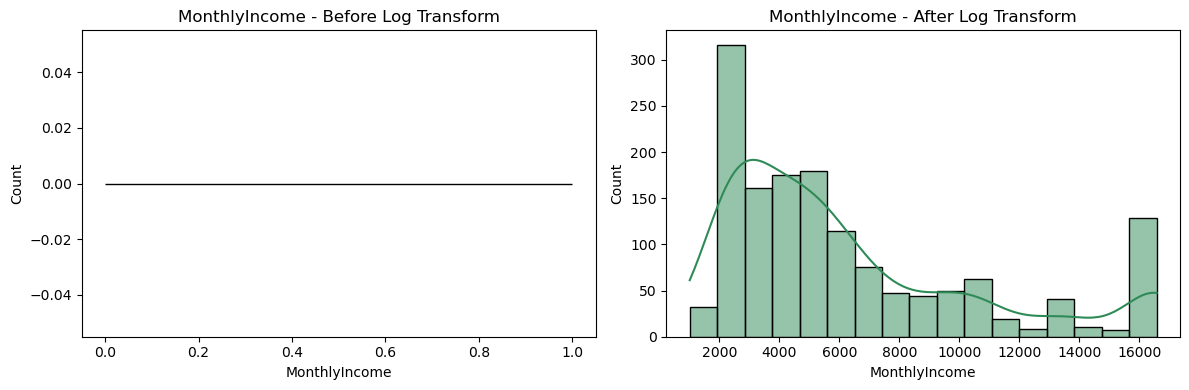

In [29]:
# Step 4: Visual before/after comparison for one example column
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.expm1(data['MonthlyIncome']), kde=True, ax=axes[0], color='salmon')
axes[0].set_title('MonthlyIncome - Before Log Transform')
sns.histplot(data['MonthlyIncome'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('MonthlyIncome - After Log Transform')
plt.tight_layout()
plt.show()

In [30]:
# 1. TenureRatio — proportion of total working life spent at this company
data['TenureRatio'] = data['YearsAtCompany'] / (data['TotalWorkingYears'] + 1)

In [31]:
# 2. PromotionGap — years stuck without a promotion, relative to tenure
data['PromotionGap'] = data['YearsSinceLastPromotion'] / (data['YearsAtCompany'] + 1)

In [32]:
# 3. IncomePerJobLevel — income normalized by seniority level
data['IncomePerJobLevel'] = data['MonthlyIncome'] / (data['JobLevel'] + 1)

In [33]:
# 4. AvgSatisfaction — combined average across all satisfaction-related scores
satisfaction_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 
                      'RelationshipSatisfaction', 'WorkLifeBalance']
data['AvgSatisfaction'] = data[satisfaction_cols].mean(axis=1)

In [34]:
# Sanity check — inspect the new features
data[['TenureRatio', 'PromotionGap', 'IncomePerJobLevel', 'AvgSatisfaction']].describe()

,TenureRatio,PromotionGap,IncomePerJobLevel,AvgSatisfaction
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.570631,0.227046,1894.570465,2.730952
std,0.274055,0.255635,664.314573,0.505815
min,0.000000,0.000000,504.500000,1.000000
25%,0.370066,0.000000,1384.000000,2.500000
50%,0.610169,0.142857,1782.166667,2.750000
75%,0.818182,0.394737,2319.583333,3.000000
max,0.947368,0.875000,3439.250000,4.000000


In [35]:
# Optional: check correlation of new features with Attrition
df_check = data.copy()
df_check['Attrition_num'] = df_check['Attrition'].map({'Yes': 1, 'No': 0})
new_feat_corr = df_check[['TenureRatio', 'PromotionGap', 'IncomePerJobLevel', 
                            'AvgSatisfaction', 'Attrition_num']].corr()['Attrition_num']
print(new_feat_corr)

TenureRatio         -0.091318
PromotionGap         0.013134
IncomePerJobLevel   -0.170857
AvgSatisfaction     -0.159092
Attrition_num        1.000000
Name: Attrition_num, dtype: float64


In [36]:
# Step 1: Identify remaining categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [37]:
# Step 2: Separate binary vs multi-category columns
binary_cols = [col for col in categorical_cols if data[col].nunique() == 2]
multi_cols = [col for col in categorical_cols if data[col].nunique() > 2]
print("Binary columns:", binary_cols)
print("Multi-category columns:", multi_cols)

Binary columns: ['Attrition', 'Gender', 'OverTime']
Multi-category columns: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']


In [38]:
# Step 3: Label encode binary columns (Attrition, OverTime, Gender)
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Attrition: {'No': np.int64(0), 'Yes': np.int64(1)}
Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
OverTime: {'No': np.int64(0), 'Yes': np.int64(1)}


In [39]:
# Step 4: One-hot encode multi-category columns
data = pd.get_dummies(data, columns=multi_cols, drop_first=True)
print("New shape after one-hot encoding:", data.shape)

New shape after one-hot encoding: (1470, 49)


In [40]:
# Step 5: Verify no object/string columns remain
remaining_object_cols = data.select_dtypes(include=['object']).columns.tolist()
print("Remaining non-numeric columns:", remaining_object_cols)  # should be empty list
data.dtypes.value_counts()

Remaining non-numeric columns: []


int64      21
bool       19
float64     9
Name: count, dtype: int64

In [41]:
data.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


In [42]:
data.dtypes

Age                                    int64
Attrition                              int64
DailyRate                              int64
DistanceFromHome                       int64
Education                              int64
EnvironmentSatisfaction                int64
Gender                                 int64
HourlyRate                             int64
JobInvolvement                         int64
JobLevel                               int64
JobSatisfaction                        int64
MonthlyIncome                          int64
MonthlyRate                            int64
NumCompaniesWorked                   float64
OverTime                               int64
PercentSalaryHike                      int64
PerformanceRating                      int64
RelationshipSatisfaction               int64
StockOptionLevel                       int64
TotalWorkingYears                    float64
TrainingTimesLastYear                  int64
WorkLifeBalance                        int64
YearsAtCom

In [43]:
# Convert all boolean columns to integers (True/False -> 1/0)
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

# Verify
print(data.dtypes.value_counts())
data[bool_cols].head()
data.head()

int64      40
float64     9
Name: count, dtype: int64


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,0,1,0,0,1
1,49,0,279,8,1,3,1,61,2,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,...,0,1,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,...,0,0,0,0,0,1,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,...,0,1,0,0,0,0,0,0,1,0


In [44]:
from sklearn.model_selection import train_test_split


In [45]:
X = data.drop(columns=['Attrition'])
y= data['Attrition']

In [46]:
print("X shape:",X.shape)
print("y shape:",y.shape)
print("\nTarget distribution:\n", y.value_counts(normalize=True))

X shape: (1470, 48)
y shape: (1470,)

Target distribution:
 Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64


In [47]:
# Step 2: Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (1176, 48) Test shape: (294, 48)

Train target distribution:
 Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Test target distribution:
 Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [48]:
# Step 3: Sanity check — confirm split ratios match
print("Overall ratio:", y.value_counts(normalize=True).values)
print("Train ratio:  ", y_train.value_counts(normalize=True).values)
print("Test ratio:   ", y_test.value_counts(normalize=True).values)

Overall ratio: [0.83877551 0.16122449]
Train ratio:   [0.83843537 0.16156463]
Test ratio:    [0.84013605 0.15986395]


In [49]:
from sklearn.preprocessing import RobustScaler

In [50]:
numeric_cols_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
binary_like_cols = [col for col in numeric_cols_to_scale if X_train[col].nunique() <= 2]
cols_to_scale = [col for col in numeric_cols_to_scale if col not in binary_like_cols]


In [51]:
print("Columns to scale:", cols_to_scale)

Columns to scale: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TenureRatio', 'PromotionGap', 'IncomePerJobLevel', 'AvgSatisfaction']


In [52]:
# Step 2: Fit RobustScaler on TRAINING data only
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [53]:
# Step 3: Sanity check — compare stats before/after scaling
print("Before scaling (train):\n", X_train[cols_to_scale].describe().loc[['mean', 'std']])


Before scaling (train):
             Age   DailyRate  DistanceFromHome  Education  \
mean  36.998299  803.991497          9.357993   2.906463   
std    9.178142  401.339423          8.179803   1.027996   

      EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
mean                 2.716837   65.500000        2.737245  2.076531   
std                  1.088707   20.373324        0.703673  1.091987   

      JobSatisfaction  MonthlyIncome  ...  TrainingTimesLastYear  \
mean         2.719388    6417.077381  ...               2.760204   
std          1.110644    4334.426071  ...               1.256262   

      WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  \
mean         2.757653        6.664116            4.213435   
std          0.718113        4.973489            3.513309   

      YearsSinceLastPromotion  YearsWithCurrManager  TenureRatio  \
mean                 1.920493              4.181973     0.573468   
std                  2.480703              3.518288    

In [54]:
print("\nAfter scaling (train):\n", X_train_scaled[cols_to_scale].describe().loc[['mean', 'std']])


After scaling (train):
            Age  DailyRate  DistanceFromHome  Education  \
mean  0.076792   0.006516          0.196499  -0.046769   
std   0.706011   0.582284          0.681650   0.513998   

      EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
mean                -0.141582   -0.014286       -0.262755  0.038265   
std                  0.544353    0.582095        0.703673  0.545994   

      JobSatisfaction  MonthlyIncome  ...  TrainingTimesLastYear  \
mean        -0.140306       0.258123  ...              -0.239796   
std          0.555322       0.792038  ...               1.256262   

      WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  \
mean        -0.242347        0.237731            0.242687   
std          0.718113        0.710498            0.702662   

      YearsSinceLastPromotion  YearsWithCurrManager  TenureRatio  \
mean                 0.306831              0.236395    -0.082813   
std                  0.826901              0.703658     0.616

In [55]:
# Step 4: Confirm shapes are unchanged (scaling doesn't add/remove rows or columns)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1176, 48)
X_test_scaled shape: (294, 48)


In [56]:
from imblearn.over_sampling import SMOTE

In [57]:
print("Before SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

Before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64


In [58]:
# Step 2: Apply SMOTE — ONLY on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())
print(y_train_resampled.value_counts(normalize=True) * 100)


After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64
Attrition
0    50.0
1    50.0
Name: proportion, dtype: float64


In [59]:
# Step 3: Sanity check — confirm test set was NOT touched
print("y_test distribution (should still be ~84/16, untouched):")
print(y_test.value_counts(normalize=True) * 100)

print("\nX_train_resampled shape:", X_train_resampled.shape)
print("X_test_scaled shape (unchanged):", X_test_scaled.shape)

y_test distribution (should still be ~84/16, untouched):
Attrition
0    84.013605
1    15.986395
Name: proportion, dtype: float64

X_train_resampled shape: (1972, 48)
X_test_scaled shape (unchanged): (294, 48)


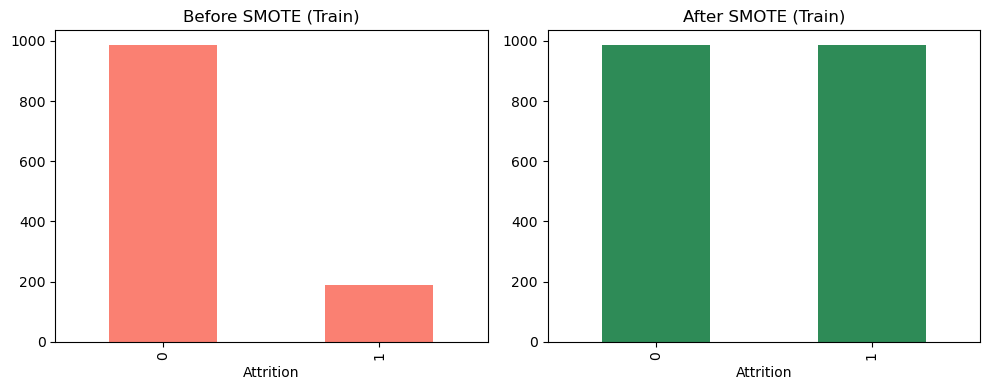

In [60]:
# Step 4: Visualize before/after class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Before SMOTE (Train)')
y_train_resampled.value_counts().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('After SMOTE (Train)')
plt.tight_layout()
plt.show()

In [61]:
import sys
!{sys.executable} -m pip install xgboost

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, 
                               roc_auc_score, f1_score, ConfusionMatrixDisplay)

In [63]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

log_reg_search = RandomizedSearchCV(
    log_reg, log_reg_params, n_iter=10, cv=5, 
    scoring='f1', random_state=42, n_jobs=-1
)
log_reg_search.fit(X_train_resampled, y_train_resampled)

print("Best Logistic Regression params:", log_reg_search.best_params_)
best_log_reg = log_reg_search.best_estimator_

Best Logistic Regression params: {'solver': 'liblinear', 'penalty': 'l2', 'C': 1}


In [64]:

rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf, rf_params, n_iter=20, cv=5, 
    scoring='f1', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_resampled, y_train_resampled)

print("Best Random Forest params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_

Best Random Forest params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [65]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb, xgb_params, n_iter=20, cv=5, 
    scoring='f1', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_resampled, y_train_resampled)

print("Best XGBoost params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

Best XGBoost params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.7}



Logistic Regression
              precision    recall  f1-score   support

          No       0.89      0.86      0.88       247
         Yes       0.39      0.47      0.42        47

    accuracy                           0.80       294
   macro avg       0.64      0.66      0.65       294
weighted avg       0.81      0.80      0.80       294

ROC-AUC: 0.7065208028253942


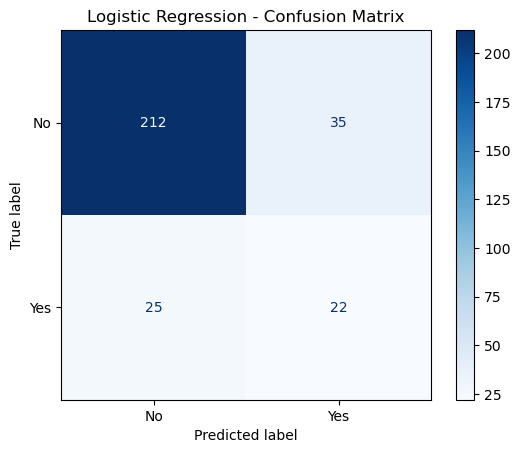


Random Forest
              precision    recall  f1-score   support

          No       0.87      0.94      0.90       247
         Yes       0.44      0.23      0.31        47

    accuracy                           0.83       294
   macro avg       0.65      0.59      0.60       294
weighted avg       0.80      0.83      0.81       294

ROC-AUC: 0.7300801102592815


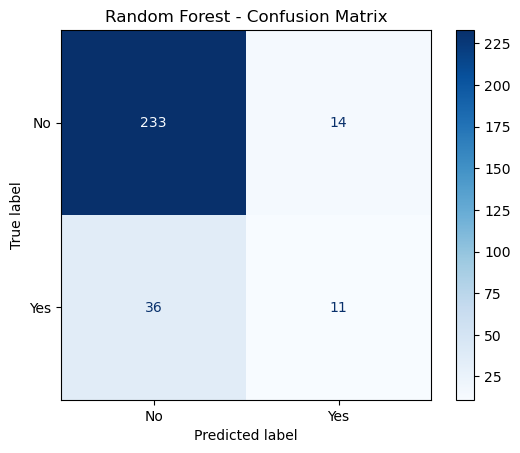


XGBoost
              precision    recall  f1-score   support

          No       0.87      0.94      0.90       247
         Yes       0.44      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.66      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294

ROC-AUC: 0.7538116978206564


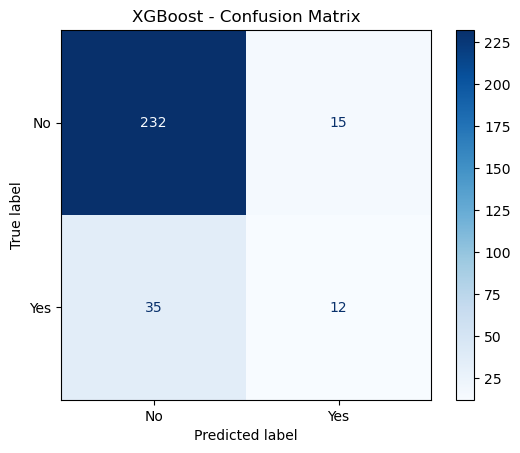

In [66]:
models = {
    'Logistic Regression': best_log_reg,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

In [67]:
# Step: Compare all three models side by side
results_summary = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results_summary.append({
        'Model': name,
        'F1 (Yes class)': f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results_summary).sort_values('F1 (Yes class)', ascending=False)
print(results_df)

                 Model  F1 (Yes class)   ROC-AUC
0  Logistic Regression        0.423077  0.706521
2              XGBoost        0.324324  0.753812
1        Random Forest        0.305556  0.730080


In [68]:
# Assume best_rf or best_xgb is the winner based on your F1 comparison
# (using best_xgb here as example — swap in whichever model actually won)

importances = best_xgb.feature_importances_
feature_names = X_train_resampled.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_importance_df.head(15))

                              Feature  Importance
17                   StockOptionLevel    0.103277
8                            JobLevel    0.062357
43         JobRole_Research Scientist    0.048206
24               YearsWithCurrManager    0.041709
46              MaritalStatus_Married    0.035403
31  Department_Research & Development    0.030685
4             EnvironmentSatisfaction    0.029939
28                    AvgSatisfaction    0.028449
41     JobRole_Manufacturing Director    0.026050
9                     JobSatisfaction    0.025810
7                      JobInvolvement    0.023639
35             EducationField_Medical    0.023448
40                    JobRole_Manager    0.023382
21                     YearsAtCompany    0.022907
20                    WorkLifeBalance    0.022902


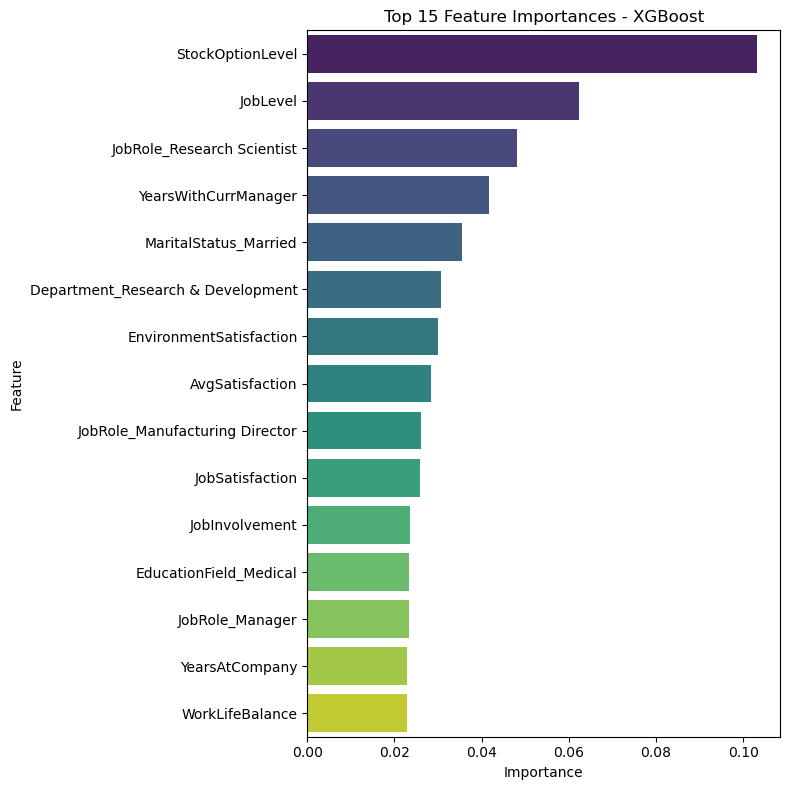

In [69]:
plt.figure(figsize=(8, 8))
sns.barplot(data=feat_importance_df.head(15), x='Importance', y='Feature', 
            hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Feature Importances - XGBoost')
plt.tight_layout()
plt.show()

In [70]:
# Sanity check: do your engineered features show up as meaningful?
engineered = ['TenureRatio', 'PromotionGap', 'IncomePerJobLevel', 'AvgSatisfaction']
print(feat_importance_df[feat_importance_df['Feature'].isin(engineered)])

              Feature  Importance
28    AvgSatisfaction    0.028449
27  IncomePerJobLevel    0.014405
26       PromotionGap    0.012832
25        TenureRatio    0.012742


In [71]:
import joblib

# Save the winning model
joblib.dump(best_xgb, 'attrition_model.pkl')

# Save the scaler (needed to transform new/incoming data the same way)
joblib.dump(scaler, 'robust_scaler.pkl')

# Save the label encoders (needed to decode categorical inputs consistently)
joblib.dump(label_encoders, 'label_encoders.pkl')

# Save the exact column order used in training (critical for one-hot encoded data)
joblib.dump(X_train_resampled.columns.tolist(), 'model_columns.pkl')

print("All artifacts saved successfully.")

All artifacts saved successfully.


In [72]:
# Quick verification — reload and confirm it works
loaded_model = joblib.load('attrition_model.pkl')
test_pred = loaded_model.predict(X_test_scaled)
print("Reloaded model prediction matches original:", 
      (test_pred == best_xgb.predict(X_test_scaled)).all())

Reloaded model prediction matches original: True
